In [95]:
import numpy as np

數據：
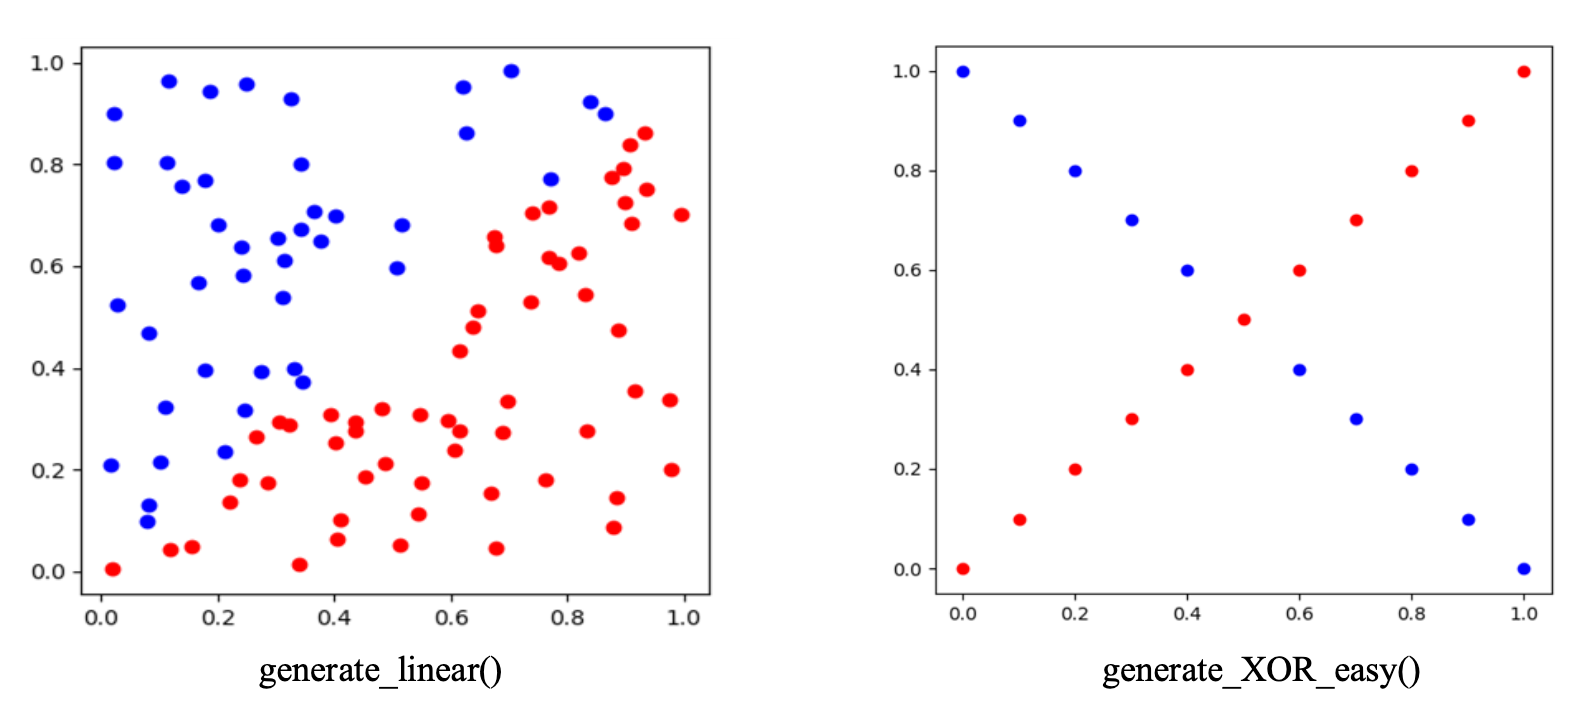

In [96]:
def generate_linear(n=100):
    import numpy as np

    pts = np.random.uniform(0, 1, (n, 2))
    inputs = []
    labels = []
    for pt in pts:
        inputs.append([pt[0], pt[1]])
        distance = (pt[0] - pt[1]) / 1.414
        if pt[0] > pt[1]:
            labels.append(0)
        else:
            labels.append(1)
    return np.array(inputs), np.array(labels).reshape(n, 1)


def generate_XOR_easy():
    import numpy as np

    inputs = []
    labels = []

    for i in range(11):
        inputs.append([0.1 * i, 0.1 * i])
        labels.append(0)

        if 0.1 * i == 0.5:
            continue

        inputs.append([0.1 * i, 1 - 0.1 * i])
        labels.append(1)

    return np.array(inputs), np.array(labels).reshape(21, 1)


# x, y = generate_linear(n=100)
# x, y = generate_XOR_easy()

In [97]:
def show_result(x, y, pred_y):
    import matplotlib.pyplot as plt

    plt.subplot(1, 2, 1)
    plt.title("Ground truth", fontsize=18)
    for i in range(x.shape[0]):
        if y[i] == 0:
            plt.plot(x[i][0], x[i][1], "ro")
        else:
            plt.plot(x[i][0], x[i][1], "bo")

    plt.subplot(1, 2, 2)
    plt.title("Predict result", fontsize=18)
    for i in range(x.shape[0]):
        if pred_y[i] == 0:
            plt.plot(x[i][0], x[i][1], "ro")
        else:
            plt.plot(x[i][0], x[i][1], "bo")

    plt.show()

In [98]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def derivative_sigmoid(x):
    return np.multiply(x, 1.0 - x)

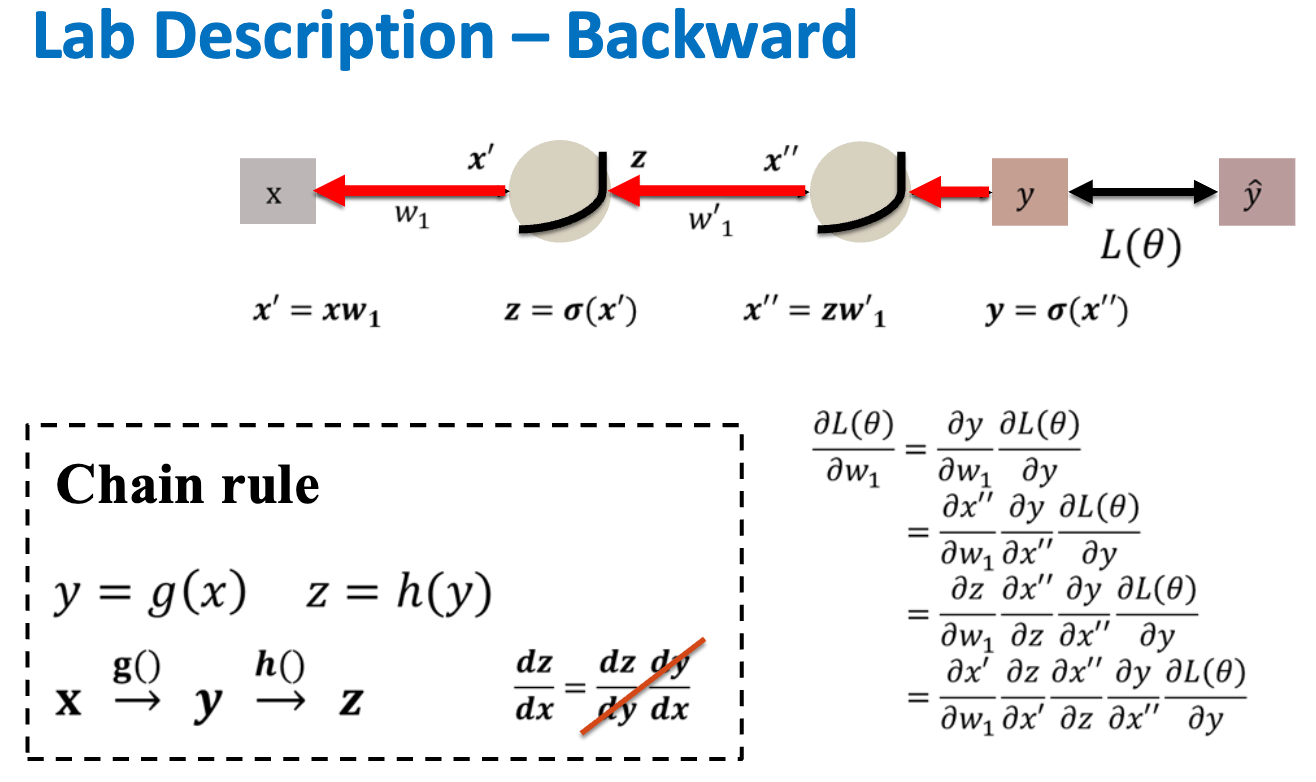
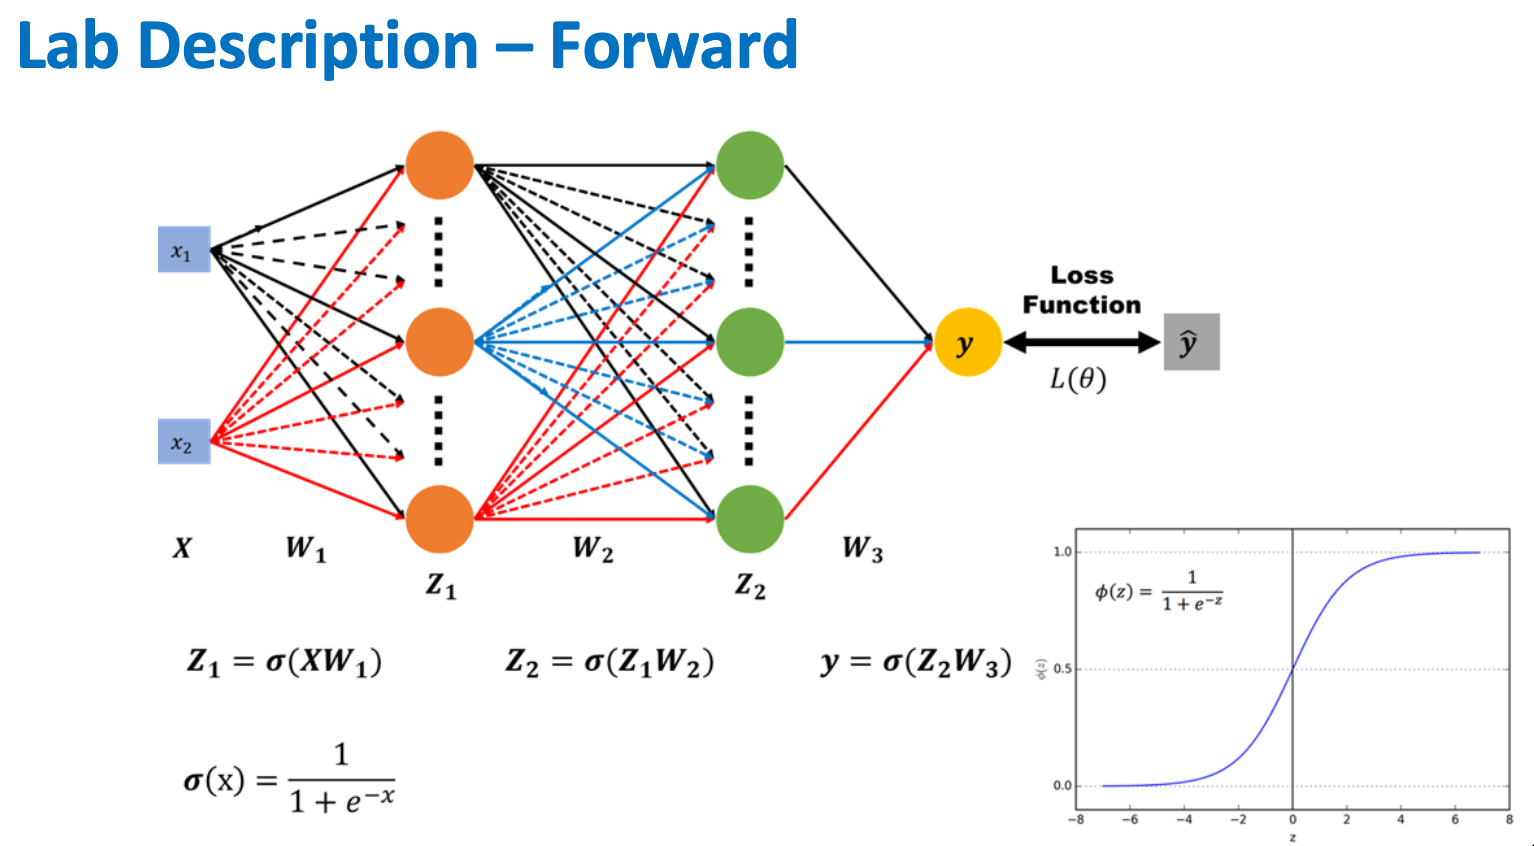

由架構：$x' = xW_1 + b_1$, $z = \sigma(x')$, $x'' = zW_2 + b_2$, $\hat{y} = \sigma(x'')$

已知 $L = \frac{1}{m} \sum (\hat{y}-y)^2$, $\frac{\partial L}{\partial \hat{y}} = \frac{2}{m}(\hat{y}-y)$

$$
\frac{\partial L}{\partial x''} = \sigma(x'')(1 - \sigma(x''))
$$

$$
\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial x''} \frac{\partial x''}{\partial W_2} = \frac{\partial L}{\partial x''} z
$$

$$
\frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial x''} \frac{\partial x''}{\partial b_2} = \frac{\partial L}{\partial x''}
$$

$$
\frac{\partial L}{\partial x'} = \frac{\partial L}{\partial x''} \frac{\partial x''}{\partial z} \frac{\partial z}{\partial x'} = \frac{\partial L}{\partial x''} W_2 \sigma(x')(1 - \sigma(x'))
$$

$$
\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial x'} \frac{\partial x'}{\partial W_1} = \frac{\partial L}{\partial x'} x
$$

$$
\frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial x'} \frac{\partial x'}{\partial b_1} = \frac{\partial L}{\partial x'}
$$

為了避免混淆，先固定符號：

- 矩陣乘法：$A @ B$（等價於數學記號 $AB$）
- 逐元素乘法（Hadamard）：$A \odot B$
- 轉置：$A^T$
- 對 batch 維度加總：$\sum_{i=1}^m(\cdot)_i$

維度：
- $x \in \mathbb{R}^{m \times d_{in}}$
- $W_1 \in \mathbb{R}^{d_{in} \times d_h},\ b_1 \in \mathbb{R}^{1 \times d_h}$
- $a_1=\sigma(x@W_1+b_1) \in \mathbb{R}^{m \times d_h}$
- $W_2 \in \mathbb{R}^{d_h \times d_{out}},\ b_2 \in \mathbb{R}^{1 \times d_{out}}$
- $\hat{y}=\sigma(a_1@W_2+b_2),\ y \in \mathbb{R}^{m \times d_{out}}$

令 $L=\frac{1}{m}\sum(\hat{y}-y)^2$，則

$$
\frac{\partial L}{\partial \hat{y}}=\frac{2}{m}(\hat{y}-y)
$$

$$
\frac{\partial L}{\partial x''}=\frac{\partial L}{\partial \hat{y}}\odot\hat{y}\odot(1-\hat{y})
$$

$$
\frac{\partial L}{\partial W_2}=a_1^T@\frac{\partial L}{\partial x''},\qquad
\frac{\partial L}{\partial b_2}=\sum_{i=1}^{m}\left(\frac{\partial L}{\partial x''}\right)_i
$$

$$
\frac{\partial L}{\partial x'}=\left(\frac{\partial L}{\partial x''}@W_2^T\right)\odot a_1\odot(1-a_1)
$$

$$
\frac{\partial L}{\partial W_1}=x^T@\frac{\partial L}{\partial x'},\qquad
\frac{\partial L}{\partial b_1}=\sum_{i=1}^{m}\left(\frac{\partial L}{\partial x'}\right)_i
$$

補充：矩陣乘法微分規則（簡短版）

採用 differential + trace 定義：
$$
dL=\mathrm{Tr}\!\left(\left(\frac{\partial L}{\partial X}\right)^T dX\right)
$$

若前向為 $Z=X@W$，則
$$
dZ=dX@W+X@dW
$$

先看對 $W$ 的導數：
$$
dL=\mathrm{Tr}\!\left(\left(\frac{\partial L}{\partial Z}\right)^T X\,dW\right)=\mathrm{Tr}\!\left(\left(X^T\frac{\partial L}{\partial Z}\right)^T dW\right)
$$
所以
$$
\frac{\partial L}{\partial W}=X^T\frac{\partial L}{\partial Z}
$$

再看對 $X$ 的導數：
$$
dL=\mathrm{Tr}\!\left(\left(\frac{\partial L}{\partial Z}\right)^T dX\,W\right)=\mathrm{Tr}\!\left(\left(\frac{\partial L}{\partial Z}W^T\right)^T dX\right)
$$
所以
$$
\frac{\partial L}{\partial X}=\frac{\partial L}{\partial Z}W^T
$$

結論：$X^T$ 與 $W^T$ 的位置來自矩陣微分推導，不是靠湊維度。

In [103]:
class modle:
    def __init__(
        self, input_size, hidden_size1, hidden_size2, output_size, learning_rate
    ):
        self.input_size = input_size
        self.hidden_size1 = hidden_size1
        self.hidden_size2 = hidden_size2
        self.output_size = output_size
        self.learning_rate = learning_rate

        # Small random init helps avoid early sigmoid saturation
        self.W1 = np.random.randn(input_size, hidden_size1) * 0.1
        self.W2 = np.random.randn(hidden_size1, output_size) * 0.1
        self.b1 = np.zeros((1, hidden_size1))
        self.b2 = np.zeros((1, output_size))

    def forward(self, x):
        self.x = x
        self.z1 = np.dot(x, self.W1) + self.b1  # x'
        self.a1 = sigmoid(self.z1)  # z

        self.z2 = np.dot(self.a1, self.W2) + self.b2  # x''
        self.a2 = sigmoid(self.z2)  # y_hat

        return self.a2

    def backward(self, x, y_pred, y):
        # MSE: mean((y_pred - y)^2)
        batch_size = x.shape[0]
        dL_dy_pred = (2.0 / batch_size) * (y_pred - y)

        delt2 = dL_dy_pred * self.a2 * (1 - self.a2)
        dL_dw2 = self.a1.T @ delt2
        dL_db2 = np.sum(delt2, axis=0, keepdims=True)

        delt1 = (delt2 @ self.W2.T) * self.a1 * (1 - self.a1)
        dL_dw1 = x.T @ delt1
        dL_db1 = np.sum(delt1, axis=0, keepdims=True)

        self.W1 -= self.learning_rate * dL_dw1
        self.W2 -= self.learning_rate * dL_dw2
        self.b1 -= self.learning_rate * dL_db1
        self.b2 -= self.learning_rate * dL_db2

        return np.mean((y_pred - y) ** 2)

    def train(self, x, y, epochs, batch_size, print_every=100):
        for epoch in range(epochs):
            epoch_loss = 0.0
            for i in range(0, x.shape[0], batch_size):
                x_batch = x[i : i + batch_size]
                y_batch = y[i : i + batch_size]

                y_pred = self.forward(x_batch)
                batch_loss = self.backward(x_batch, y_pred, y_batch)
                epoch_loss += batch_loss

            avg_epoch_loss = epoch_loss / (x.shape[0] / batch_size)
            if (epoch + 1) % print_every == 0 or epoch == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.6f}")

    def test(self, x, y, threshold=0.5, show_plot=True):
        y_true = np.asarray(y).reshape(-1, 1)
        y_pred = self.forward(x)

        pred_labels = (y_pred >= threshold).astype(int)
        accuracy = float(np.mean(pred_labels == y_true))
        mse = float(np.mean((y_pred - y_true) ** 2))
        print(f"Test Accuracy: {accuracy:.4f}, MSE: {mse:.6f}")
        for i in range(y_pred.shape[0]):
            print(
                f"Iter {i:<3}  |   True={y_true[i][0]:<3}   |   Predicted={y_pred[i][0]:.4f}({pred_labels[i][0]})"
            )
        if show_plot:
            show_result(x, y_true, pred_labels)

        return y_pred

In [108]:
x_train, y_train = generate_XOR_easy()
learning_rates = 0.3
epochs = 10000
batch_size = 4

net = modle(
    input_size=2,
    hidden_size1=4,
    hidden_size2=8,
    output_size=1,
    learning_rate=learning_rates,
)


net.train(x_train, y_train, epochs=epochs, batch_size=batch_size, print_every=1000)

Epoch 1/10000, Loss: 0.288745
Epoch 1000/10000, Loss: 0.181213
Epoch 2000/10000, Loss: 0.031526
Epoch 3000/10000, Loss: 0.008537
Epoch 4000/10000, Loss: 0.003686
Epoch 5000/10000, Loss: 0.002149
Epoch 6000/10000, Loss: 0.001461
Epoch 7000/10000, Loss: 0.001085
Epoch 8000/10000, Loss: 0.000853
Epoch 9000/10000, Loss: 0.000697
Epoch 10000/10000, Loss: 0.000586


Test Accuracy: 1.0000, MSE: 0.000625
Iter 0    |   True=0     |   Predicted=0.0239(0)
Iter 1    |   True=1     |   Predicted=0.9991(1)
Iter 2    |   True=0     |   Predicted=0.0239(0)
Iter 3    |   True=1     |   Predicted=0.9991(1)
Iter 4    |   True=0     |   Predicted=0.0238(0)
Iter 5    |   True=1     |   Predicted=0.9989(1)
Iter 6    |   True=0     |   Predicted=0.0238(0)
Iter 7    |   True=1     |   Predicted=0.9982(1)
Iter 8    |   True=0     |   Predicted=0.0237(0)
Iter 9    |   True=1     |   Predicted=0.9361(1)
Iter 10   |   True=0     |   Predicted=0.0237(0)
Iter 11   |   True=0     |   Predicted=0.0237(0)
Iter 12   |   True=1     |   Predicted=0.9466(1)
Iter 13   |   True=0     |   Predicted=0.0236(0)
Iter 14   |   True=1     |   Predicted=0.9990(1)
Iter 15   |   True=0     |   Predicted=0.0236(0)
Iter 16   |   True=1     |   Predicted=0.9992(1)
Iter 17   |   True=0     |   Predicted=0.0236(0)
Iter 18   |   True=1     |   Predicted=0.9992(1)
Iter 19   |   True=0     |   Pre

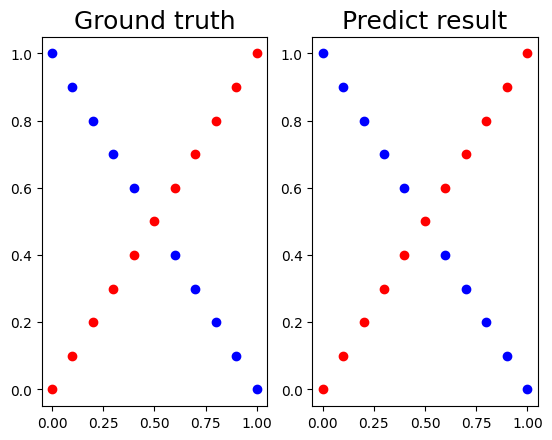

In [107]:
x_test, y_test = generate_XOR_easy()
y_pred = net.test(x_test, y_test, threshold=0.5, show_plot=True)

In [111]:
x_train, y_train = generate_linear(n=100)
learning_rates = 0.3
epochs = 10000
batch_size = 4

net2 = modle(
    input_size=2,
    hidden_size1=4,
    hidden_size2=8,
    output_size=1,
    learning_rate=learning_rates,
)


net2.train(x_train, y_train, epochs=epochs, batch_size=batch_size, print_every=1000)

Epoch 1/10000, Loss: 0.252638
Epoch 1000/10000, Loss: 0.007772
Epoch 2000/10000, Loss: 0.003161
Epoch 3000/10000, Loss: 0.001715
Epoch 4000/10000, Loss: 0.001104
Epoch 5000/10000, Loss: 0.000787
Epoch 6000/10000, Loss: 0.000600
Epoch 7000/10000, Loss: 0.000479
Epoch 8000/10000, Loss: 0.000395
Epoch 9000/10000, Loss: 0.000334
Epoch 10000/10000, Loss: 0.000288


Test Accuracy: 1.0000, MSE: 0.000852
Iter 0    |   True=1     |   Predicted=0.9999(1)
Iter 1    |   True=0     |   Predicted=0.0000(0)
Iter 2    |   True=0     |   Predicted=0.0000(0)
Iter 3    |   True=0     |   Predicted=0.0000(0)
Iter 4    |   True=0     |   Predicted=0.0000(0)
Iter 5    |   True=0     |   Predicted=0.0000(0)
Iter 6    |   True=0     |   Predicted=0.0000(0)
Iter 7    |   True=0     |   Predicted=0.0000(0)
Iter 8    |   True=0     |   Predicted=0.0000(0)
Iter 9    |   True=1     |   Predicted=1.0000(1)
Iter 10   |   True=0     |   Predicted=0.0000(0)
Iter 11   |   True=1     |   Predicted=1.0000(1)
Iter 12   |   True=0     |   Predicted=0.0000(0)
Iter 13   |   True=1     |   Predicted=1.0000(1)
Iter 14   |   True=0     |   Predicted=0.0000(0)
Iter 15   |   True=1     |   Predicted=1.0000(1)
Iter 16   |   True=0     |   Predicted=0.0000(0)
Iter 17   |   True=1     |   Predicted=1.0000(1)
Iter 18   |   True=0     |   Predicted=0.0000(0)
Iter 19   |   True=0     |   Pre

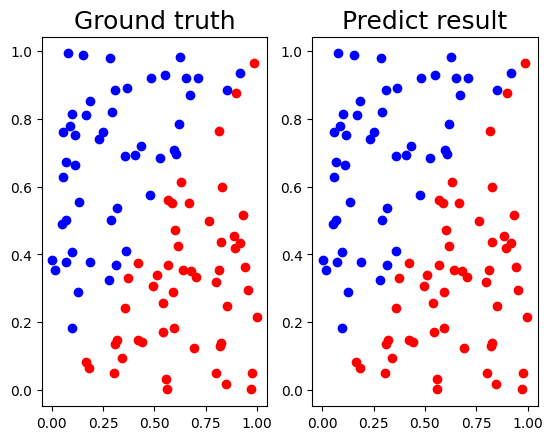

In [115]:
x_test, y_test = generate_linear(n=100)
y_pred = net2.test(x_test, y_test, threshold=0.5, show_plot=True)